# **Implementación del caso de 5 Qubits**

Implementacion del algoritmo de Schnorr-Yan para factorizar **N = 48567227** para una instancia de CVP

In [69]:
%load_ext autoreload
%autoreload 2

from modules import schnorr_lattice as sl
from modules import qaoa as q

from modules import utils

import numpy as np
import matplotlib.pyplot as plt
from qiskit.visualization import plot_histogram

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [70]:
seed = 99

In [71]:
N5 = 48567227

In [72]:
fiveQubit = sl.schnorrCVP(N5, 4, 1, seed)

El numero de bits de N = 48567227 es m = 26
La dimension del reticulo que vamos a tratar es n = 5
La cota smooth que vamos a tomar: 50


## **1. Algoritmo de Schnorr**

In [73]:
cvpinstance = fiveQubit.generate_cvp(10)

B = 
[ 2 0 0 0 0  6931 ]
[ 0 1 0 0 0 10986 ]
[ 0 0 3 0 0 16094 ]
[ 0 0 0 2 0 19459 ]
[ 0 0 0 0 1 23979 ]
t = 
(0, 0, 0, 0, 0, 176985)


In [74]:
cvpResult = fiveQubit.babai_algorithm(cvpinstance, delta = 0.75)
print(f'D5 = \n{cvpResult.D}\n')
print(f'b_op5 = \n{cvpResult.b_op}\n')
print(f'res_vector5 = \n{cvpResult.res_vector}\n')
print(f'step_sign5 = \n{cvpResult.step_sign}\n')
print(f'weights5 = \n{cvpResult.weight}\n')

D5 = 
[  6 -4  6  4 -2  -3 ]
[ -8 -3  6 -2  2   5 ]
[  2 11  3  0 -6  -3 ]
[ -4 -5  0 12 -2   4 ]
[ -4 -3 -3  4  1 -17 ]

b_op5 = 
[     2      4      9      8      0 176993]

res_vector5 = 
[-2 -4 -9 -8  0 -8]

step_sign5 = 
[-1 -1 -1 -1  1]

weights5 = 
(-3092, -354, -1837, 3883, -8732)



## **2. Algoritmo QAOA**

In [75]:
qubo5 = q.define_qubo(cvpResult.D, cvpResult.res_vector, cvpResult.step_sign, fiveQubit.n)
print(qubo5.prettyprint())

Hc5, offset5 = q.define_hamiltonian(qubo5)
print(f'Offset = {offset5}')
print(f'Hamiltonian = \n{Hc5}')

Problem name: quboProblem

Minimize
  117*z_0^2 - 54*z_0*z_1 + 14*z_0*z_2 + 72*z_0*z_3 - 70*z_0*z_4 + 142*z_1^2
  - 116*z_1*z_2 + 78*z_1*z_3 + 136*z_1*z_4 + 179*z_2^2 - 126*z_2*z_3
  + 10*z_2*z_4 + 205*z_3^2 - 18*z_3*z_4 + 340*z_4^2 - 116*z_0 - 100*z_1
  - 102*z_2 - 200*z_3 - 302*z_4 + 229

Subject to
  No constraints

  Binary variables (5)
    z_0 z_1 z_2 z_3 z_4

Offset = 292.0
Hamiltonian = 
SparsePauliOp(['IIIIZ', 'IIIZI', 'IIZII', 'IZIII', 'ZIIII', 'IIIZZ', 'IIZIZ', 'IZIIZ', 'ZIIIZ', 'IIZZI', 'IZIZI', 'ZIIZI', 'IZZII', 'ZIZII', 'ZZIII'],
              coeffs=[  9. +0.j, -32. +0.j,  16. +0.j,  -4. +0.j, -33.5+0.j, -13.5+0.j,
   3.5+0.j,  18. +0.j, -17.5+0.j, -29. +0.j,  19.5+0.j,  34. +0.j,
 -31.5+0.j,   2.5+0.j,  -4.5+0.j])


In [76]:
formatted_h = " + ".join([f"{c.real:.3f}{s}" for s, c in Hc5.label_iter()])
print(formatted_h)

9.000IIIIZ + -32.000IIIZI + 16.000IIZII + -4.000IZIII + -33.500ZIIII + -13.500IIIZZ + 3.500IIZIZ + 18.000IZIIZ + -17.500ZIIIZ + -29.000IIZZI + 19.500IZIZI + 34.000ZIIZI + -31.500IZZII + 2.500ZIZII + -4.500ZZIII


     ┌───┐ ┌─────────────┐                                              »
q_0: ┤ H ├─┤ Rz(18*γ[0]) ├───■────────────────■────────────■────────────»
     ├───┤┌┴─────────────┴─┐ │ZZ((-27)*γ[0])  │            │            »
q_1: ┤ H ├┤ Rz((-64)*γ[0]) ├─■────────────────┼────────────┼────────────»
     ├───┤└┬─────────────┬─┘                  │ZZ(7*γ[0])  │            »
q_2: ┤ H ├─┤ Rz(32*γ[0]) ├────────────────────■────────────┼────────────»
     ├───┤┌┴─────────────┴┐                                │ZZ(36*γ[0]) »
q_3: ┤ H ├┤ Rz((-8)*γ[0]) ├────────────────────────────────■────────────»
     ├───┤├───────────────┴┐                                            »
q_4: ┤ H ├┤ Rz((-67)*γ[0]) ├────────────────────────────────────────────»
     └───┘└────────────────┘                                            »
«                                       ┌────────────┐┌─────────────┐»
«q_0: ──────────────────■───────────────┤ Rx(2*β[0]) ├┤ Rz(18*γ[1]) ├»
«                       │               └───

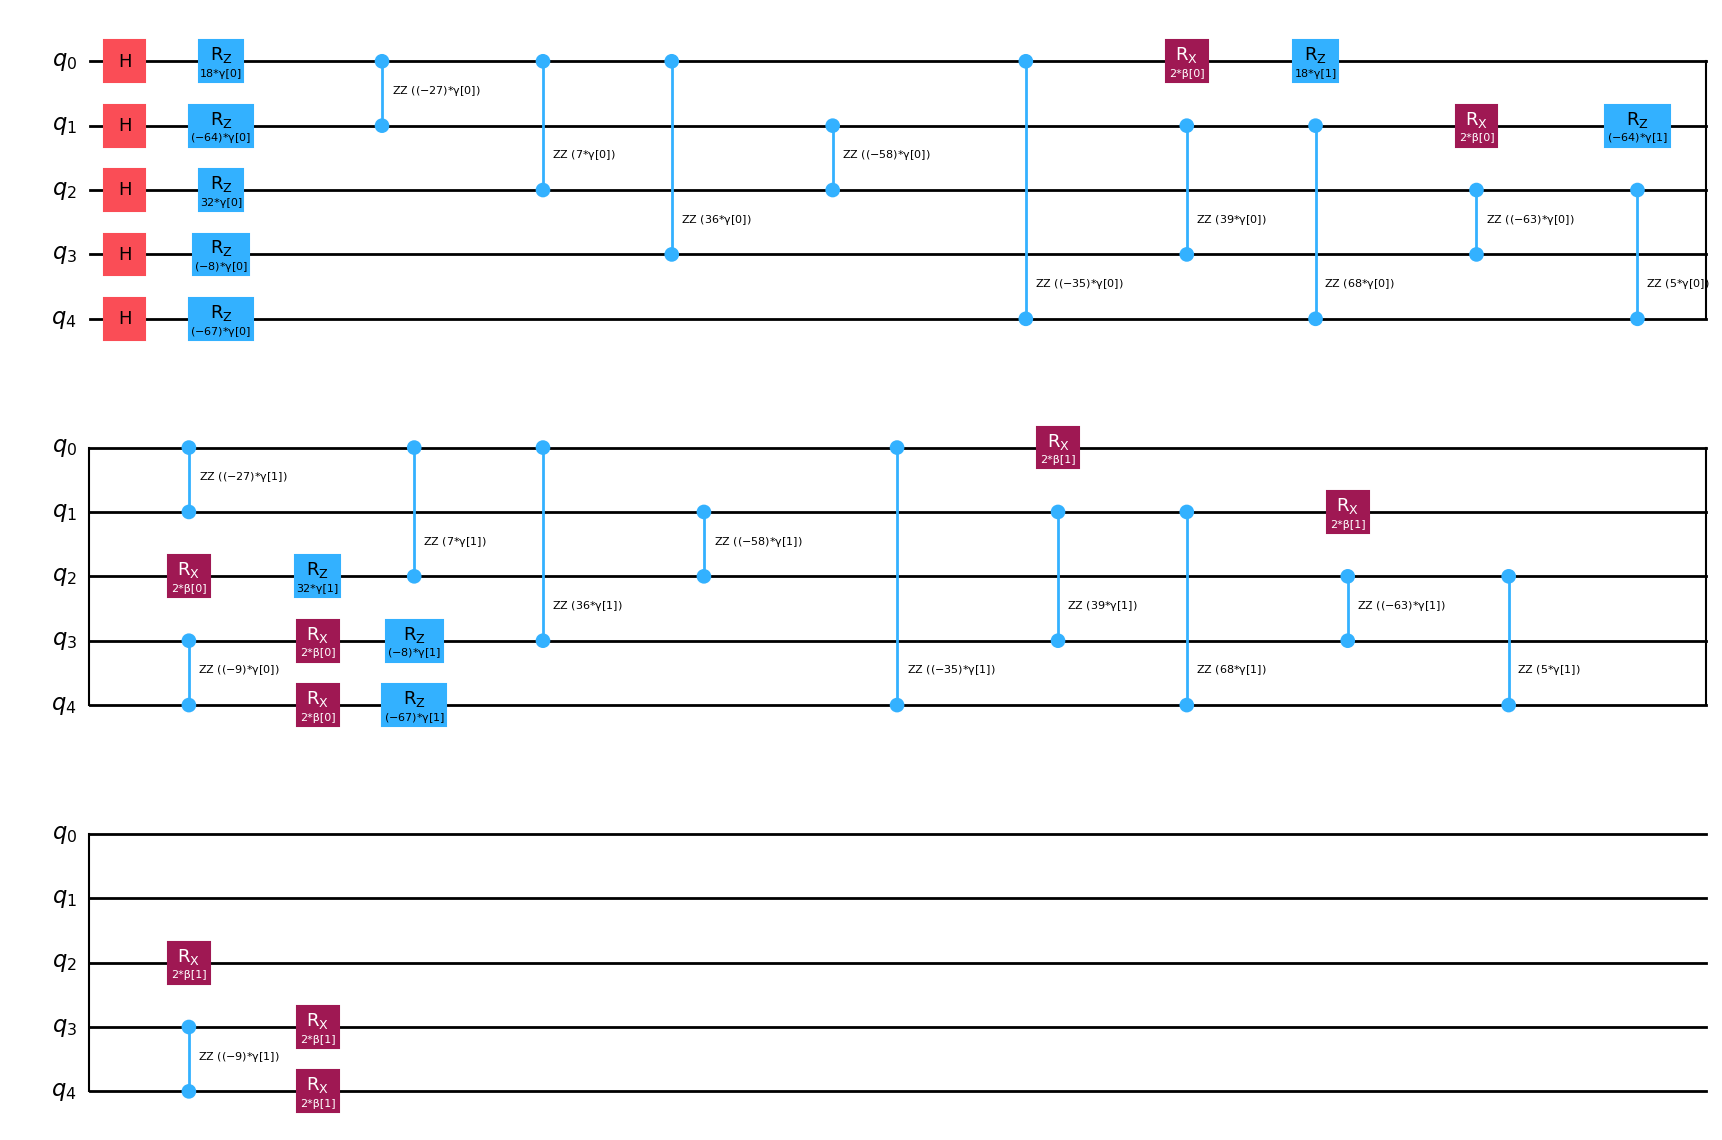

In [77]:
circuit5 = q.construct_circuit(Hc5, reps= 2)
print(circuit5)
fig = circuit5.draw('mpl') #Muestro el circuito
fig.savefig("figures/circuito_5cubits_p2.png", dpi = 150, bbox_inches = "tight")
fig

In [78]:
x0 = np.asarray([0.0]*circuit5.num_parameters)
#x0 = np.random.uniform(0, 2*np.pi, circuit5.num_parameters)
monitor, optParameters10 = q.qaoa_algorithm(circuit5, Hc5, x0)

In [79]:
print(f'Iteraciones = {monitor.iterations}')
print(f'Evolucion: ')
for angles, value in zip(monitor.parameters, monitor.evaluation):
    print(f'{angles}: {value}')

Iteraciones = 232
Evolucion: 
[ 0.0001875  0.0001875  0.0001875 -0.0005   ]: -0.0010249247495824985
[ 0.00032813  0.00032813 -0.00035937 -0.000375  ]: -0.01568037015391748
[ 0.00032813  0.00032813 -0.00035937 -0.000375  ]: -0.01568037015391748
[ 0.00032813  0.00032813 -0.00035937 -0.000375  ]: -0.01568037015391748
[ 0.00058887  0.00082324 -0.00029004 -0.00147656]: -0.07032566983929094
[ 0.00058887  0.00082324 -0.00029004 -0.00147656]: -0.07032566983929094
[ 0.00058887  0.00082324 -0.00029004 -0.00147656]: -0.07032566983929094
[ 0.00127911  0.0012879  -0.00119135 -0.00197412]: -0.23766022810289927
[ 0.00135173  0.00211711 -0.00126845 -0.00329846]: -0.4635517444503595
[ 0.00135173  0.00211711 -0.00126845 -0.00329846]: -0.4635517444503595
[ 0.00266206  0.00277275 -0.00173739 -0.00527956]: -0.8973580075863247
[ 0.00384635  0.00440334 -0.00333999 -0.0071279 ]: -1.8235923410796555
[ 0.00384635  0.00440334 -0.00333999 -0.0071279 ]: -1.8235923410796555
[ 0.00559878  0.00641984 -0.00457249 -0.0

In [80]:
for param in optParameters10.items():
    print(f'{param[0]} = {param[1]}')

β[0] = 0.4735522944974848
β[1] = 0.1959455355651294
γ[0] = -0.00859819181543771
γ[1] = -0.019938932910216145


In [81]:
results5= q.sample_from_parameters(circuit5, list(optParameters10.values()), shots = 10_000)
print(len(results5))
for bitstring, count in results5.items():
    print(f"Bistring: {bitstring} -> Counts: {count}")

31
Bistring: 01100 -> Counts: 1864
Bistring: 00111 -> Counts: 1533
Bistring: 10001 -> Counts: 1190
Bistring: 00001 -> Counts: 921
Bistring: 01110 -> Counts: 703
Bistring: 00000 -> Counts: 692
Bistring: 11101 -> Counts: 672
Bistring: 11100 -> Counts: 439
Bistring: 01111 -> Counts: 350
Bistring: 00011 -> Counts: 341
Bistring: 01000 -> Counts: 268
Bistring: 00110 -> Counts: 203
Bistring: 11001 -> Counts: 158
Bistring: 01101 -> Counts: 145
Bistring: 11000 -> Counts: 130
Bistring: 10111 -> Counts: 111
Bistring: 10000 -> Counts: 38
Bistring: 11010 -> Counts: 32
Bistring: 10011 -> Counts: 29
Bistring: 10101 -> Counts: 28
Bistring: 11110 -> Counts: 26
Bistring: 11111 -> Counts: 23
Bistring: 00101 -> Counts: 21
Bistring: 11011 -> Counts: 20
Bistring: 01001 -> Counts: 19
Bistring: 00010 -> Counts: 15
Bistring: 10010 -> Counts: 8
Bistring: 01010 -> Counts: 7
Bistring: 10100 -> Counts: 5
Bistring: 01011 -> Counts: 5
Bistring: 00100 -> Counts: 4


## **3. Obtención de SR-Pairs**

In [82]:
nD5 = sl.integer_to_matrix(cvpResult.D)
vnew5 = sl.bitstring2latticeVectors(nD5, results5.keys(), cvpResult.step_sign, cvpResult.b_op)

In [83]:
distances5 = utils.get_distances(vnew5, cvpinstance.t)

In [84]:
nB5 = sl.integer_to_matrix(cvpinstance.B)
uv_pairs5 = sl.vectors2uv_pairs(nB5, vnew5, fiveQubit.n)
for pair5 in uv_pairs5:
    print(pair5)

[21435888100 441]
[1215290846 25]
[776562633 16]
[194500845 4]
[340139712 7]
[48620250 1]
[285311670611 5880]
[11789738455 243]
[416713664664 8575]
[243045684 5]
[2381643000 49]
[3937140592 81]
[9509900499 196]
[233436821409 4802]
[48514950 1]
[327520882997 6750]
[97060425 2]
[48498912 1]
[1212977997 25]
[5661432406091 116640]
[2182563152 45]
[42443058438 875]
[10503585169 216]
[8488175652 175]
[116712415215 2401]
[5881105440 121]
[533655864 11]
[340122240 7]
[11463230904895 236196]
[83338451856 1715]
[106337949025 2187]


In [85]:
sr_pairs5 = sl.uv_pairs2sr_pairs(uv_pairs5, fiveQubit)
print(sr_pairs5)

[((11789738455, 243), -12097706)]


In [86]:
probs5 = utils.get_probs(results5.values(), shots = 10_000)

In [87]:
utils.prettyprint(vnew5, distances5, probs5, cvpResult.b_op, cvpResult.res_vector)

Vector más corto por algoritmo de Babai: 
b_op = [     2      4      9      8      0 176993]

El vector residual 
t - b_op = [-2 -4 -9 -8  0 -8]

La distancia |t - b_op| = 15.133

0: Prob = 0.18640
	vnew = [     4     -2      6     -4      8 176992] con distancia: 13.601
1: Prob = 0.15330
	vnew = [     2      0     -6      6      6 176994] con distancia: 13.892
2: Prob = 0.11900
	vnew = [    -8      5      0      8      3 176979] con distancia: 14.071
3: Prob = 0.09210
	vnew = [    -4      8      3      4      2 176996] con distancia: 15.166
4: Prob = 0.07030
	vnew = [    12      1      0     -2      6 176987] con distancia: 13.748
5: Prob = 0.06920
	vnew = [     2      4      9      8      0 176993] con distancia: 15.133
6: Prob = 0.06720
	vnew = [    -6     -1     -3     -4     11 176978] con distancia: 15.232
7: Prob = 0.04390
	vnew = [     0     -5      3      0      9 176975] con distancia: 14.663
8: Prob = 0.03500
	vnew = [     6      5     -6     -6      8 176990] con distancia:

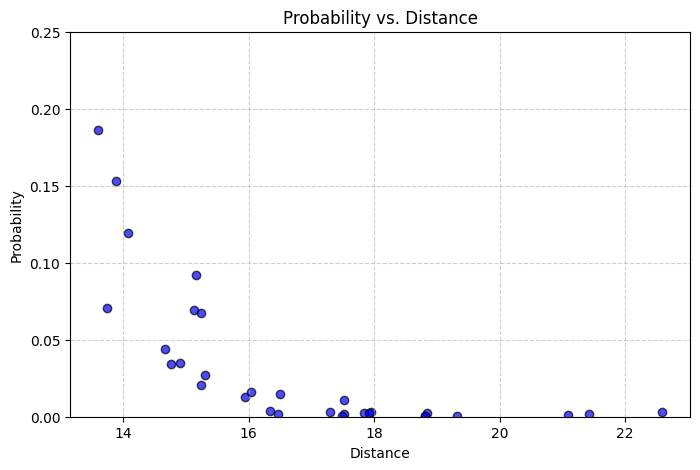

In [88]:
plt.figure(figsize=(8, 5))

# Creating the scatter plot
plt.scatter(distances5, probs5, color='blue', edgecolors='black', alpha=0.7)

# Adding labels and title
plt.xlabel('Distance')
plt.ylabel('Probability')
plt.title('Probability vs. Distance')

# Setting y-axis limit since you mentioned probs are <= 0.2
plt.ylim(0, 0.25) 

plt.grid(True, linestyle='--', alpha=0.6)
plt.savefig("figures/5QubitCase_ProbsDistances.png", dpi=150, bbox_inches="tight")
plt.show()